# 🧭 Clustering Jerárquico & DBSCAN — solución comentada

Esta es mi versión resuelta del notebook del reto. La dejo aquí, en el repo, para quien quiera repasar la sesión por su cuenta o comparar su solución con la mía.

No la uses para copiar y pegar antes de intentarlo por tu cuenta — la gracia está en pelearte un rato con el `# TODO` primero.

## 0. Setup

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)

## 1. El territorio: generamos los datos

Simulo tres "nubes" de puntos (como tres poblados en un mapa) y añado un par de puntos sueltos que no pertenecen a ninguna. Esta parte es la misma en el notebook con TODO — no hace falta tocarla, es el punto de partida para el reto.

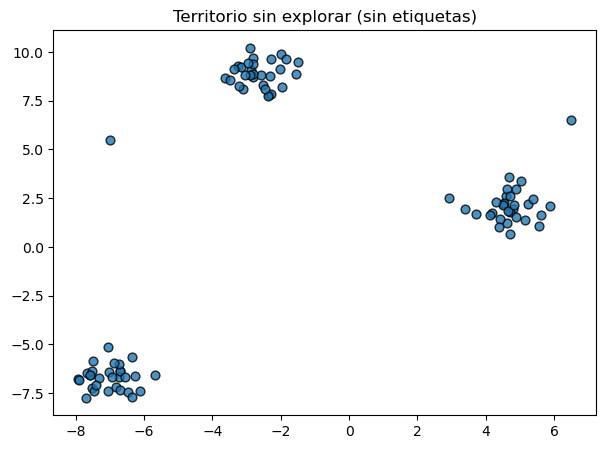

In [6]:
# Tres nubes de puntos
X_blobs, _ = make_blobs(n_samples=90, centers=3, cluster_std=0.65, random_state=42)

# Puntos sueltos (outliers), lejos de las nubes
outliers = np.array([
    [ 6.5,  6.5],
    [-7.0,  5.5],
])

X = np.vstack([X_blobs, outliers])

plt.scatter(X[:, 0], X[:, 1], s=40, edgecolor='k', alpha=0.8)
plt.title("Territorio sin explorar (sin etiquetas)")
plt.show()

## 2. Clustering Jerárquico

### 2.1 Matriz de enlaces y dendrograma

Uso `linkage()` con `method='ward'` porque, de los cuatro (single, complete, average, ward), es el que menos "efecto cadena" me da en la práctica: minimiza la varianza dentro de cada grupo en vez de fijarse solo en el punto más cercano o más lejano.

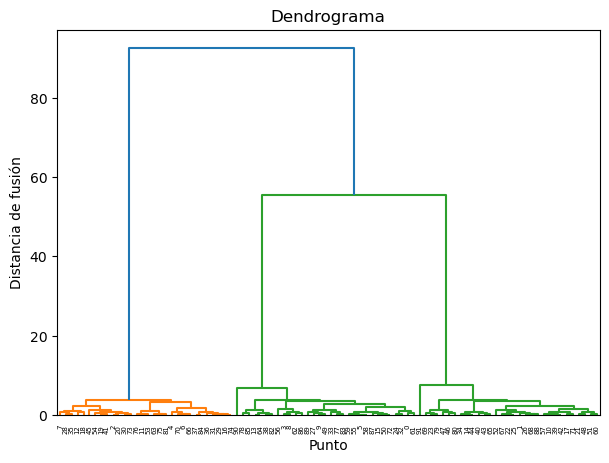

In [7]:
Z = linkage(X, method='ward')

dendrogram(Z)
plt.title("Dendrograma")
plt.xlabel("Punto")
plt.ylabel("Distancia de fusión")
plt.show()

# Lo que miro aquí: los dos "saltos" más altos del árbol suelen marcar
# el corte más natural. Con 3 nubes + 2 puntos sueltos, espero ver
# indicios de que hacen falta más de 3 grupos si quiero aislar a los sueltos.

### 2.2 Cortar el árbol y entrenar el modelo final

Con 3 nubes reales + 2 puntos sueltos, si quiero que **cada punto suelto tenga su propio grupo**, necesito `n_clusters=5` (3 nubes + 2 singletons). Si me quedo en `n_clusters=3`, el árbol los absorbe dentro de la nube más próxima — que es exactamente lo que quiero que el equipo descubra en el reto.

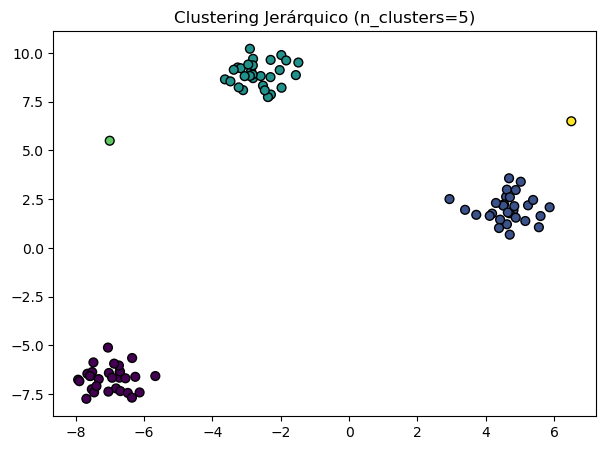

In [8]:
n_clusters = 5

modelo_jerarquico = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels_jerarquico = modelo_jerarquico.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels_jerarquico, cmap='viridis', s=40, edgecolor='k')
plt.title(f"Clustering Jerárquico (n_clusters={n_clusters})")
plt.show()

# Con n_clusters=5, cada punto suelto forma su propio grupo (de tamaño 1).
# Bájalo a 3 y ejecuta de nuevo esta celda: verás cómo cada outlier
# se funde con la nube real más cercana. Ese contraste es justo la
# demo que quiero que vea el equipo en directo.

**Lo que le pido al equipo que observe:** el jerárquico nunca deja a nadie fuera para siempre — solo depende de a qué altura corto el árbol. Con pocos clusters, todo se funde; con muchos, hasta el punto más raro acaba teniendo "su" grupo. Eso es una decisión mía, no algo que el algoritmo decida solo.

## 3. DBSCAN

### 3.1 Escalado

Escalo siempre antes de DBSCAN: mide distancias absolutas, y si no normalizo, una variable con más rango domina el cálculo sin que eso tenga ningún sentido conceptual.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 3.2 Modelo DBSCAN

Empiezo con `eps=0.5` y `min_samples=5` (valores razonables después de escalar) y reviso cuánto ruido me deja. Si me sale casi todo en `-1`, es señal de que `eps` se me ha quedado corto — no de que el algoritmo esté fallando.

Clusters: 3 | Ruido: 2


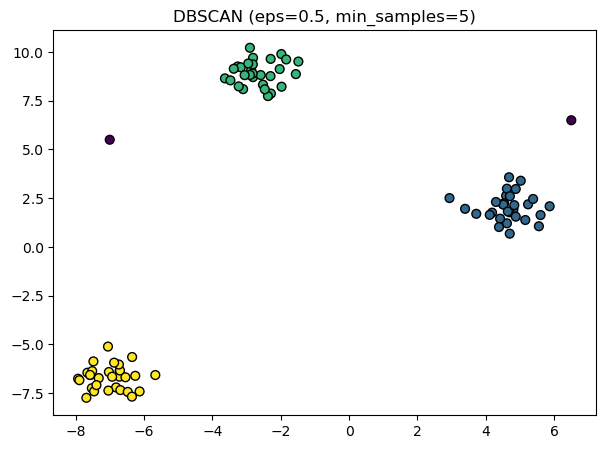

In [10]:
eps = 0.5
min_samples = 5

modelo_dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels_dbscan = modelo_dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)
print(f"Clusters: {n_clusters_dbscan} | Ruido: {n_noise}")

plt.scatter(X[:, 0], X[:, 1], c=labels_dbscan, cmap='viridis', s=40, edgecolor='k')
plt.title(f"DBSCAN (eps={eps}, min_samples={min_samples})")
plt.show()

# Con estos parámetros, mis dos puntos sueltos me salen como ruido (-1):
# no tienen suficientes vecinos dentro de eps=0.5 como para formar
# ni siquiera su propia zona densa. A diferencia del jerárquico, aquí
# no hace falta "forzar" nada — quedan fuera de forma natural.

### 3.3 Bonus — k-distance plot

En vez de elegir `eps` a ojo, esta es la forma que más uso cuando el dataset ya no es tan visual como este: grafico la distancia al k-ésimo vecino más cercano (con k = `min_samples`) y busco el "codo" de la curva. Ese codo suele ser un valor de `eps` bastante más defendible que uno elegido a mano.

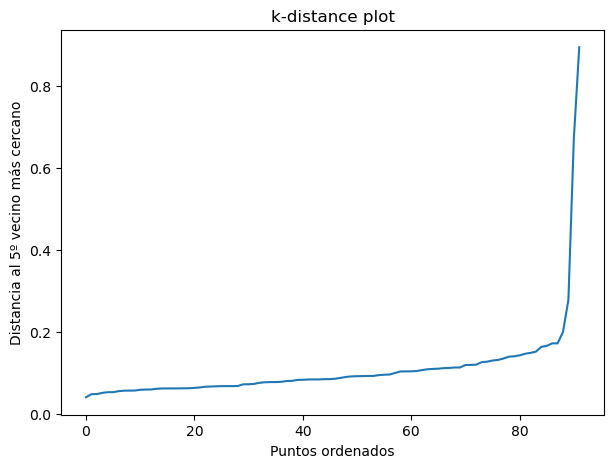

In [11]:
k = min_samples

nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.plot(k_distances)
plt.title("k-distance plot")
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {k}º vecino más cercano")
plt.show()

# El codo de esta curva (donde la pendiente se dispara) me da una
# estimación razonable de eps. En este dataset, coincide bastante
# bien con el 0.5 que usé a ojo — no siempre tengo esa suerte.

## 4. Lo que yo respondería en el reto final

1. **¿Qué `n_clusters` hace falta para que los puntos sueltos formen su propio grupo?** Con 3 nubes + 2 puntos sueltos, `n_clusters=5`. Uno más por cada punto que quiero que quede aislado.
2. **¿Qué combinación de `eps`/`min_samples` los deja como ruido en DBSCAN?** Con los datos ya escalados, `eps=0.5` y `min_samples=5` ya es suficiente en este dataset — la clave conceptual es que `eps` sea lo bastante pequeño (o `min_samples` lo bastante alto) para que esos puntos no alcancen la densidad mínima.
3. **¿Qué comportamiento prefiero si estos puntos fueran transacciones bancarias sospechosas?** El de DBSCAN. Prefiero que algo quede señalado como "esto no encaja en nada conocido" a que quede escondido dentro del cluster más parecido solo porque tiene que pertenecer a alguno.
4. **¿Jerárquico o DBSCAN para un dataset con más de 100.000 filas?** DBSCAN, sin dudarlo — el jerárquico calcula una matriz de distancias O(n²) que a ese tamaño ya no es viable sin submuestrear.
